# 5. Ridge — прозрачный линейный baseline (оба таргета)

Дополнение к ТЗ: L2-регуляризованный baseline против `DummyRegressor(mean/median)`, чтобы оценить, насколько нелинейный бустинг превосходит простую линейную зависимость.

Общий пайплайн, тайм-сплит 70/15/15 и метрики взяты из `preprocessing/preprocessing.py` и `team_modeling_protocol.txt` (через `scripts/p2_common.py`), чтобы результаты были сравнимы с другими участниками. Выбор моделей — по validation; test — только финальная оценка. Выборка — последние 30 000 строк по времени.

In [1]:
import sys
from pathlib import Path

_here = Path.cwd()
_p2 = next((b for b in [_here, *_here.parents] if (b / "scripts" / "p2_common.py").exists()), _here)
sys.path.insert(0, str(_p2 / "scripts"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import p2_common as C
from catboost import CatBoostRegressor, CatBoostClassifier, Pool

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 200)
plt.rcParams["figure.figsize"] = (7, 3.4)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3
BLUE, ORANGE, GREEN, GREY = "#2b6cb0", "#dd6b20", "#2f855a", "#a0aec0"
print("pipeline OK | OUTPUT_DIR:", C.OUTPUT_DIR.name, "| MAX_ROWS:", C.MAX_ROWS)

pipeline OK | OUTPUT_DIR: outputs | MAX_ROWS: 30000


In [2]:
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.linear_model import Ridge
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from preprocessing.preprocessing import TargetTransform

def build(num, cat, est):
    pre = ColumnTransformer([('num', StandardScaler(), num),
                             ('cat', OneHotEncoder(handle_unknown='ignore', min_frequency=0.01), cat)])
    return Pipeline([('pre', pre), ('est', est)])

In [3]:
rows = []
for target in (C.NEXT_TARGET, C.CRM_TARGET):
    pk = C.get_aug_pack(target, base_only=True)
    for mode in ('raw', 'p995', 'log1p_p995'):
        tfm = TargetTransform(mode).fit(pk.y_train)
        for alpha in (0.1, 1.0, 10.0, 100.0):
            model = build(pk.num_cols, pk.cat_cols, Ridge(alpha=alpha))
            model.fit(pk.x_train, tfm.transform(pk.y_train))
            ev = {s + '_' + k: v for s, X, y in [('val', pk.x_val, pk.y_val), ('test', pk.x_test, pk.y_test)]
                  for k, v in C.metric_pack(y, tfm.inverse(model.predict(X))).items()}
            rows.append(dict(target=target.replace('_sec', ''), model=f'ridge_a{alpha}_{mode}',
                             val_mae=ev['val_mae'], test_mae=ev['test_mae'], val_r2=ev['val_r2'],
                             val_small=ev['val_small_mae']))
    for strat in ('mean', 'median'):
        dm = DummyRegressor(strategy=strat).fit(pk.x_train, pk.y_train)
        ev = {s + '_' + k: v for s, X, y in [('val', pk.x_val, pk.y_val), ('test', pk.x_test, pk.y_test)]
              for k, v in C.metric_pack(y, np.maximum(dm.predict(X), 0)).items()}
        rows.append(dict(target=target.replace('_sec', ''), model=f'dummy_{strat}',
                         val_mae=ev['val_mae'], test_mae=ev['test_mae'], val_r2=ev['val_r2'],
                         val_small=ev['val_small_mae']))
ridge = pd.DataFrame(rows)
for t in ridge.target.unique():
    print('==', t, '==')
    display(ridge[ridge.target == t].sort_values('val_mae').head(5).reset_index(drop=True))

== target_next_session_length ==


,target,model,val_mae,test_mae,val_r2,val_small
0,target_next_session_length,dummy_median,555.428889,457.690889,-0.114777,196.604889
1,target_next_session_length,ridge_a100.0_p995,580.765486,496.117575,0.077363,425.901956
2,target_next_session_length,ridge_a10.0_p995,581.080035,496.395316,0.076504,425.230468
3,target_next_session_length,ridge_a1.0_p995,581.174178,496.472112,0.076261,425.197496
4,target_next_session_length,ridge_a0.1_p995,581.195723,496.482536,0.076207,425.205115


== future_sessions_mean_playtime_7d ==


,target,model,val_mae,test_mae,val_r2,val_small
0,future_sessions_mean_playtime_7d,ridge_a100.0_p995,307.617724,331.759017,0.216697,349.820980
1,future_sessions_mean_playtime_7d,ridge_a10.0_p995,308.097875,332.388147,0.215214,349.470712
2,future_sessions_mean_playtime_7d,ridge_a1.0_p995,308.242488,332.584871,0.214668,349.559852
3,future_sessions_mean_playtime_7d,ridge_a0.1_p995,308.258637,332.607044,0.214602,349.571507
4,future_sessions_mean_playtime_7d,ridge_a100.0_raw,309.293069,333.788031,0.214573,352.771127


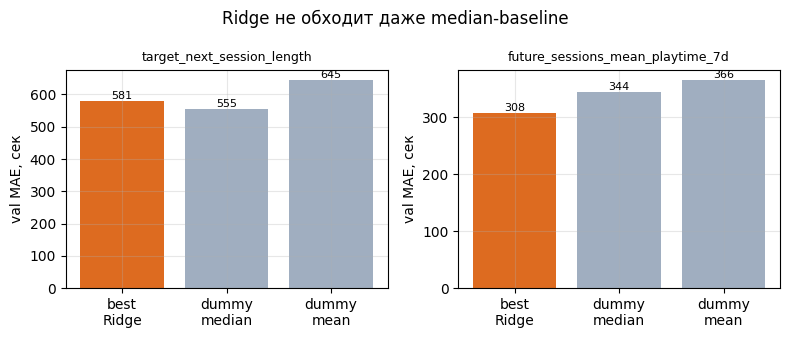

In [4]:
tgts = list(ridge.target.unique())
fig, axes = plt.subplots(1, len(tgts), figsize=(8, 3.4))
for ax, t in zip(np.atleast_1d(axes), tgts):
    sub = ridge[ridge.target == t]
    best_ridge = sub[sub.model.str.startswith('ridge')].val_mae.min()
    dmed = float(sub[sub.model == 'dummy_median'].val_mae.iloc[0])
    dmean = float(sub[sub.model == 'dummy_mean'].val_mae.iloc[0])
    vals = [best_ridge, dmed, dmean]
    ax.bar(['best\nRidge', 'dummy\nmedian', 'dummy\nmean'], vals, color=[ORANGE, GREY, GREY])
    for i, v in enumerate(vals):
        ax.text(i, v, f'{v:.0f}', ha='center', va='bottom', fontsize=8)
    ax.set_title(t, fontsize=9); ax.set_ylabel('val MAE, сек')
fig.suptitle('Ridge не обходит даже median-baseline'); plt.tight_layout(); plt.show()

**Вывод.** На next-session Ridge не обходит даже `dummy_median` (линейная модель почти бесполезна на шумном таргете); на CRM Ridge разумнее, но CatBoost всё равно сильнее. Это обосновывает пользу нелинейных взаимодействий CatBoost.